<a href="https://colab.research.google.com/github/NilayKnt/MachineLearning-w-6Models/blob/main/Machine_Learning_w_6_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
df=pd.read_csv("spaceship.csv")

In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier



In [10]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=3,
    n_informative=8,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}


model_reports = {}

for name, model in models.items():

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_test, preds, average='macro')
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(y_test, preds, average='micro')
    total_support = len(y_test)

    report_df = pd.DataFrame([
        {'Precision': acc,     'Recall': acc,     'F1-Score': acc,      'Support': total_support},
        {'Precision': macro_p, 'Recall': macro_r, 'F1-Score': macro_f1, 'Support': total_support},
        {'Precision': micro_p, 'Recall': micro_r, 'F1-Score': micro_f1, 'Support': total_support}
    ], index=['Accuracy', 'Macro Avg', 'Micro Avg'])

    model_reports[name] = report_df


for name, report in model_reports.items():
    print(f"================ {name} ================")
    print(report.round(4))
    print("\n")

================ Random Forest ================
           Precision  Recall  F1-Score  Support
Accuracy      0.8900   0.890    0.8900      200
Macro Avg     0.8892   0.889    0.8891      200
Micro Avg     0.8900   0.890    0.8900      200


================ AdaBoost ================
           Precision  Recall  F1-Score  Support
Accuracy      0.7300  0.7300    0.7300      200
Macro Avg     0.7313  0.7305    0.7304      200
Micro Avg     0.7300  0.7300    0.7300      200


================ Gradient Boosting ================
           Precision  Recall  F1-Score  Support
Accuracy      0.8700  0.8700    0.8700      200
Macro Avg     0.8702  0.8697    0.8699      200
Micro Avg     0.8700  0.8700    0.8700      200


================ Hist Gradient Boosting ================
           Precision  Recall  F1-Score  Support
Accuracy      0.8900  0.8900    0.8900      200
Macro Avg     0.8921  0.8904    0.8902      200
Micro Avg     0.8900  0.8900    0.8900      200


================ XGBoost

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [11]:
# 1. DATASET PREPARATION
feature_names = [f"Feature_{i+1}" for i in range(12)]
X, y = make_classification(
    n_samples=1200,
    n_features=12,
    n_classes=3,
    n_informative=8,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:

# 2. MODEL DEFINITION & TRAINING
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}


In [13]:
predictions = {}
summary_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds

    # Calculate Metrics
    acc = accuracy_score(y_test, preds)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_test, preds, average='macro')
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(y_test, preds, average='micro')

    summary_list.append({
        'Model': name,
        'Accuracy': acc,
        'Macro F1': macro_f1,
        'Micro F1': micro_f1
    })

df_summary = pd.DataFrame(summary_list).sort_values(by='Macro F1', ascending=False)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


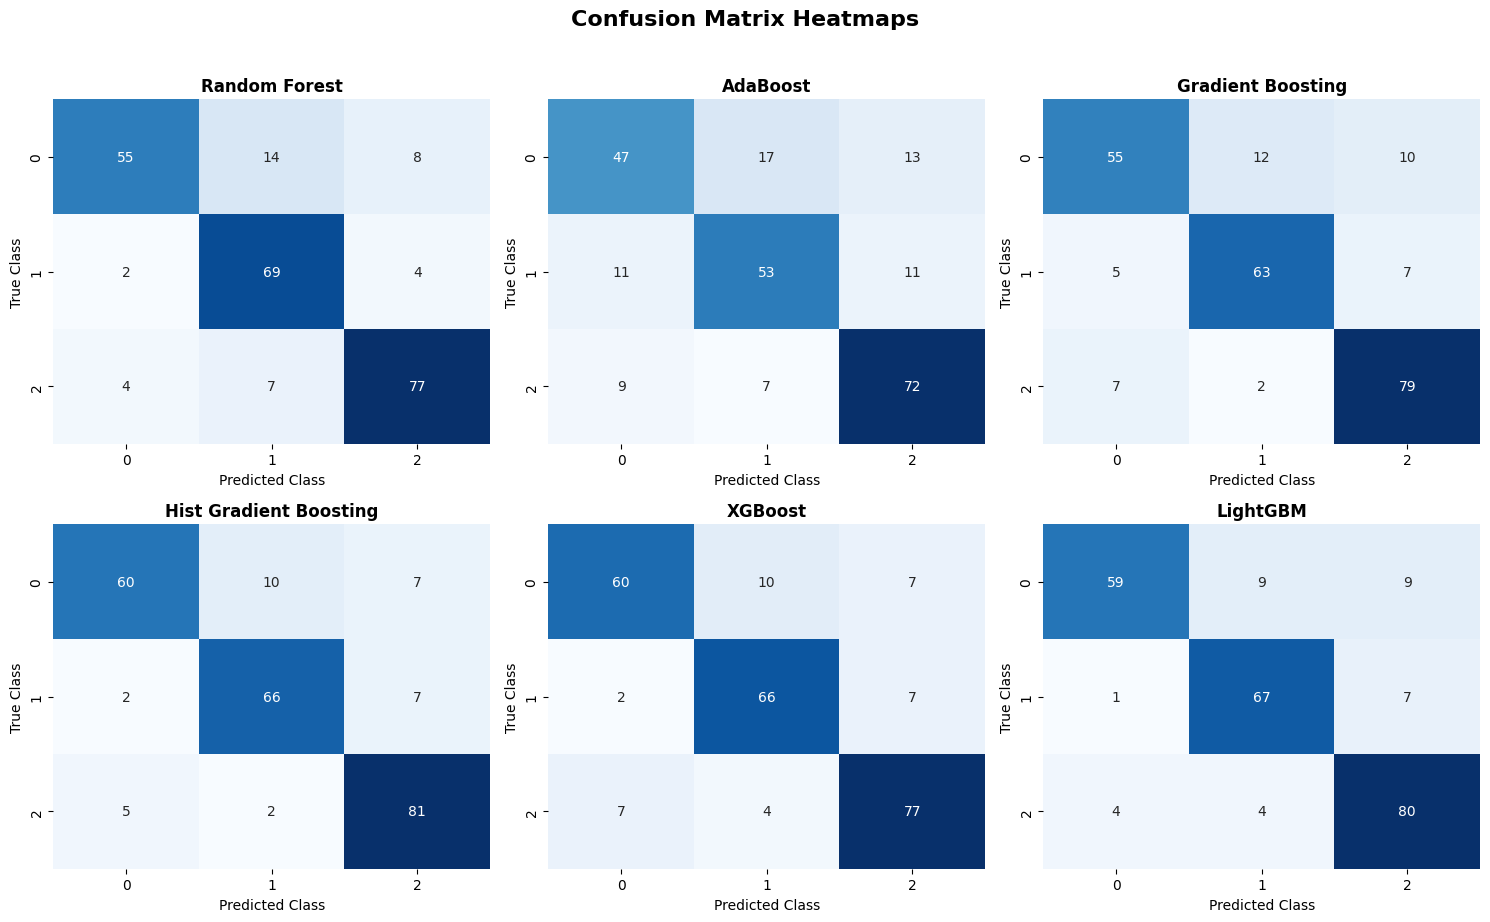

In [14]:
# ==============================================================================
# VISUALIZATION 1: CONFUSION MATRIX HEATMAPS (Side-by-Side for 6 Models)
# ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx], cbar=False
    )
    axes[idx].set_title(f"{name}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Predicted Class")
    axes[idx].set_ylabel("True Class")

plt.suptitle(
    "Confusion Matrix Heatmaps",
    fontsize=16,
    fontweight="bold",
    y=1.02
)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()



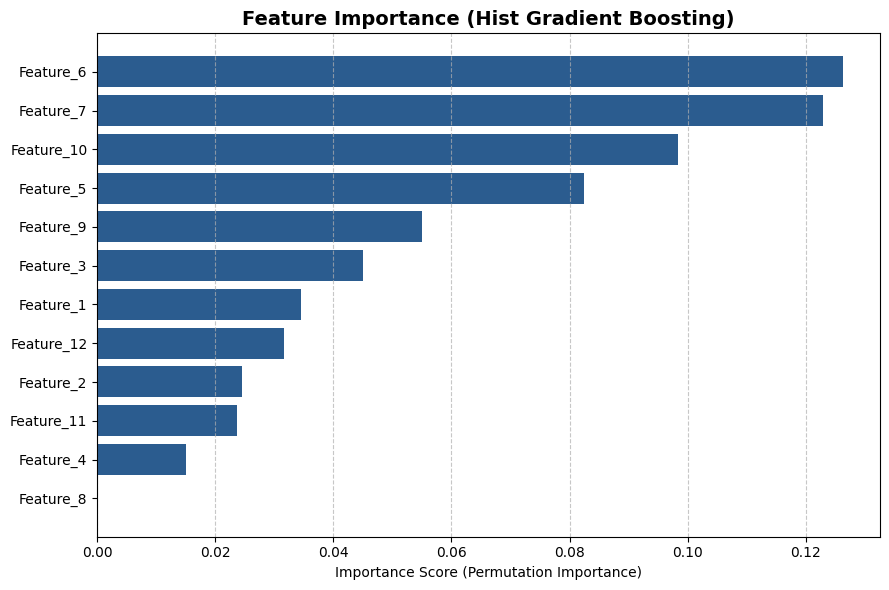

In [16]:


# ==============================================================================
# VISUALIZATION 2: FEATURE IMPORTANCE PLOT (For Best Performing Model)
# ==============================================================================
best_model_name = df_summary.iloc[0]["Model"]
best_model = models[best_model_name]

# Permutation Importance works seamlessly across all tree-based models
result = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42
)
importances = result.importances_mean

df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(
    df_importance["Feature"],
    df_importance["Importance"],
    color="#2b5c8f"
)
plt.title(
    f"Feature Importance ({best_model_name})",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Importance Score (Permutation Importance)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()